In [19]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import os
from IPython.display import clear_output
import time

In [20]:
tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.18.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [21]:
def load_and_preprocess_data():
    """Load and preprocess MNIST dataset"""
    # Load MNIST dataset
    (x_train, _), (_, _) = keras.datasets.mnist.load_data()

    # Normalize pixel values to [-1, 1] range
    x_train = (x_train.astype(np.float32) - 127.5) / 127.5

    # Reshape to add channel dimension
    x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)

    print(f"Dataset shape: {x_train.shape}")
    print(f"Data range: [{x_train.min()}, {x_train.max()}]")

    return x_train

In [22]:
def create_generator(latent_dim=100):
    """Create the generator model"""
    model = keras.Sequential([
        # Initial dense layer
        layers.Dense(7 * 7 * 256, use_bias=False, input_shape=(latent_dim,)),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        # Reshape to 7x7x256
        layers.Reshape((7, 7, 256)),

        # Upsample to 14x14x128
        layers.Conv2DTranspose(128, (5, 5), strides=(2, 2), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        # Upsample to 28x28x64
        layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        # Final layer to 28x28x1
        layers.Conv2DTranspose(1, (5, 5), strides=(1, 1), padding='same', use_bias=False, activation='tanh')
    ])

    return model


In [23]:
def create_discriminator():
    """Create the discriminator model"""
    model = keras.Sequential([
        # Input layer 28x28x1
        layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same', input_shape=[28, 28, 1]),
        layers.LeakyReLU(),
        layers.Dropout(0.3),

        # Downsample to 7x7x128
        layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'),
        layers.LeakyReLU(),
        layers.Dropout(0.3),

        # Flatten and output
        layers.Flatten(),
        layers.Dense(1)
    ])

    return model

In [24]:
cross_entropy = keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real_output, fake_output):
    """Calculate discriminator loss"""
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    total_loss = real_loss + fake_loss
    return total_loss

def generator_loss(fake_output):
    """Calculate generator loss"""
    return cross_entropy(tf.ones_like(fake_output), fake_output)

In [25]:
generator_optimizer = keras.optimizers.Adam(1e-4)
discriminator_optimizer = keras.optimizers.Adam(1e-4)

In [26]:
def setup_checkpoints(generator, discriminator):
    """Setup checkpoints for saving model weights"""
    checkpoint_dir = './training_checkpoints'
    checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt")
    checkpoint = tf.train.Checkpoint(generator_optimizer=generator_optimizer,
                                   discriminator_optimizer=discriminator_optimizer,
                                   generator=generator,
                                   discriminator=discriminator)

    return checkpoint, checkpoint_prefix


In [27]:
@tf.function
def train_step(images, generator, discriminator, latent_dim, batch_size):
    """Single training step"""
    noise = tf.random.normal([batch_size, latent_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        # Generate fake images
        generated_images = generator(noise, training=True)

        # Get discriminator outputs
        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        # Calculate losses
        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    # Calculate gradients
    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    # Apply gradients
    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    return gen_loss, disc_loss

def generate_and_save_images(model, epoch, test_input, save_dir='generated_images'):
    """Generate and save images during training"""
    os.makedirs(save_dir, exist_ok=True)

    predictions = model(test_input, training=False)

    fig = plt.figure(figsize=(4, 4))

    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i+1)
        plt.imshow(predictions[i, :, :, 0] * 127.5 + 127.5, cmap='gray')
        plt.axis('off')

    plt.savefig(f'{save_dir}/image_at_epoch_{epoch:04d}.png')
    plt.close()

def train_dcgan(dataset, epochs, generator, discriminator, checkpoint, checkpoint_prefix,
                latent_dim=100, batch_size=256, save_interval=10):
    """Main training loop"""

    # Create fixed noise for generating sample images
    seed = tf.random.normal([16, latent_dim])

    # Training metrics
    gen_losses = []
    disc_losses = []

    print("Starting training...")
    print(f"Epochs: {epochs}, Batch size: {batch_size}")
    print("-" * 50)

    # Call train_step once with dummy data to build models and initialize optimizers
    print("Initializing models and optimizers...")
    dummy_images = tf.random.normal([batch_size, 28, 28, 1])
    train_step(dummy_images, generator, discriminator, latent_dim, batch_size)
    print("Initialization complete.")
    print("-" * 50)


    for epoch in range(epochs):
        start = time.time()

        epoch_gen_loss = []
        epoch_disc_loss = []

        # Train on each batch
        for image_batch in dataset:
            gen_loss, disc_loss = train_step(image_batch, generator, discriminator, latent_dim, batch_size)
            epoch_gen_loss.append(gen_loss)
            epoch_disc_loss.append(disc_loss)

        # Calculate average losses
        avg_gen_loss = tf.reduce_mean(epoch_gen_loss)
        avg_disc_loss = tf.reduce_mean(epoch_disc_loss)

        gen_losses.append(avg_gen_loss.numpy())
        disc_losses.append(avg_disc_loss.numpy())

        # Generate and save images
        if (epoch + 1) % save_interval == 0:
            generate_and_save_images(generator, epoch + 1, seed)

        # Save checkpoint
        if (epoch + 1) % 50 == 0:
            checkpoint.save(file_prefix=checkpoint_prefix)

        # Print progress
        print(f'Epoch {epoch+1}/{epochs} - Time: {time.time()-start:.2f}s - '
              f'Gen Loss: {avg_gen_loss:.4f} - Disc Loss: {avg_disc_loss:.4f}')

    # Generate final images
    generate_and_save_images(generator, epochs, seed)

    return gen_losses, disc_losses

def plot_training_losses(gen_losses, disc_losses):
    """Plot training losses"""
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(gen_losses, label='Generator Loss')
    plt.plot(disc_losses, label='Discriminator Loss')
    plt.title('Training Losses')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(gen_losses, label='Generator Loss', alpha=0.7)
    plt.title('Generator Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

In [28]:
def main():
    """Main function to run the complete DCGAN training"""

    # Hyperparameters
    EPOCHS = 100
    BATCH_SIZE = 256
    LATENT_DIM = 100
    BUFFER_SIZE = 60000

    print("=" * 60)
    print("DCGAN FOR HANDWRITTEN DIGIT GENERATION")
    print("=" * 60)

    # Load and preprocess data
    print("\n1. Loading and preprocessing MNIST dataset...")
    train_images = load_and_preprocess_data()

    # Create dataset
    train_dataset = tf.data.Dataset.from_tensor_slices(train_images)
    train_dataset = train_dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

    # Create models
    print("\n2. Creating Generator and Discriminator models...")
    generator = create_generator(LATENT_DIM)
    discriminator = create_discriminator()

    # Print model summaries
    print("\nGenerator Architecture:")
    generator.summary()
    print("\nDiscriminator Architecture:")
    discriminator.summary()

    # Setup checkpoints
    print("\n3. Setting up checkpoints...")
    checkpoint, checkpoint_prefix = setup_checkpoints(generator, discriminator)

    # Train the model
    print("\n4. Starting training...")
    gen_losses, disc_losses = train_dcgan(
        train_dataset, EPOCHS, generator, discriminator,
        checkpoint, checkpoint_prefix, LATENT_DIM, BATCH_SIZE
    )

    # Plot training losses
    print("\n5. Plotting training losses...")
    plot_training_losses(gen_losses, disc_losses)

    # Generate final sample images
    print("\n6. Generating final sample images...")
    noise = tf.random.normal([25, LATENT_DIM])
    generated_images = generator(noise, training=False)

    # Display generated images
    plt.figure(figsize=(10, 10))
    for i in range(25):
        plt.subplot(5, 5, i+1)
        plt.imshow(generated_images[i, :, :, 0] * 127.5 + 127.5, cmap='gray')
        plt.axis('off')

    plt.suptitle('Generated Handwritten Digits', fontsize=16)
    plt.tight_layout()
    plt.show()

    print("\n" + "=" * 60)
    print("TRAINING COMPLETED SUCCESSFULLY!")
    print("Generated images saved in 'generated_images' folder")
    print("Model checkpoints saved in 'training_checkpoints' folder")
    print("=" * 60)

    return generator, discriminator, gen_losses, disc_losses

DCGAN FOR HANDWRITTEN DIGIT GENERATION

1. Loading and preprocessing MNIST dataset...
Dataset shape: (60000, 28, 28, 1)
Data range: [-1.0, 1.0]

2. Creating Generator and Discriminator models...

Generator Architecture:


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 12544)          │     1,254,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 12544)          │        50,176 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_25 (LeakyReLU)      │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_5 (Reshape)             │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_15             │ (None, 14, 14, 128)    │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_26 (LeakyReLU)      │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_16             │ (None, 28, 28, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_27 (LeakyReLU)      │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_17             │ (None, 28, 28, 1)      │         1,600 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,330,944 (8.89 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_28 (LeakyReLU)      │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_29 (LeakyReLU)      │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 212,865 (831.50 KB)

 Non-trainable params: 0 (0.00 B)


3. Setting up checkpoints...

4. Starting training...
Starting training...
Epochs: 100, Batch size: 256
--------------------------------------------------
Initializing models and optimizers...
Initialization complete.
--------------------------------------------------
Epoch 1/100 - Time: 41.12s - Gen Loss: 1.5909 - Disc Loss: 0.6375
Epoch 2/100 - Time: 21.75s - Gen Loss: 2.4779 - Disc Loss: 0.5832
Epoch 3/100 - Time: 21.86s - Gen Loss: 0.7255 - Disc Loss: 1.4569
Epoch 4/100 - Time: 21.61s - Gen Loss: 0.7660 - Disc Loss: 1.3560
Epoch 5/100 - Time: 21.58s - Gen Loss: 0.7907 - Disc Loss: 1.2865
Epoch 6/100 - Time: 21.63s - Gen Loss: 0.7851 - Disc Loss: 1.3215
Epoch 7/100 - Time: 21.70s - Gen Loss: 0.8164 - Disc Loss: 1.2902
Epoch 8/100 - Time: 21.67s - Gen Loss: 0.7766 - Disc Loss: 1.3402
Epoch 9/100 - Time: 21.64s - Gen Loss: 0.8469 - Disc Loss: 1.2991
Epoch 10/100 - Time: 21.97s - Gen Loss: 0.7960 - Disc Loss: 1.3059
Epoch 11/100 - Time: 21.57s - Gen Loss: 0.8398 - Disc Loss: 1.2756
Ep

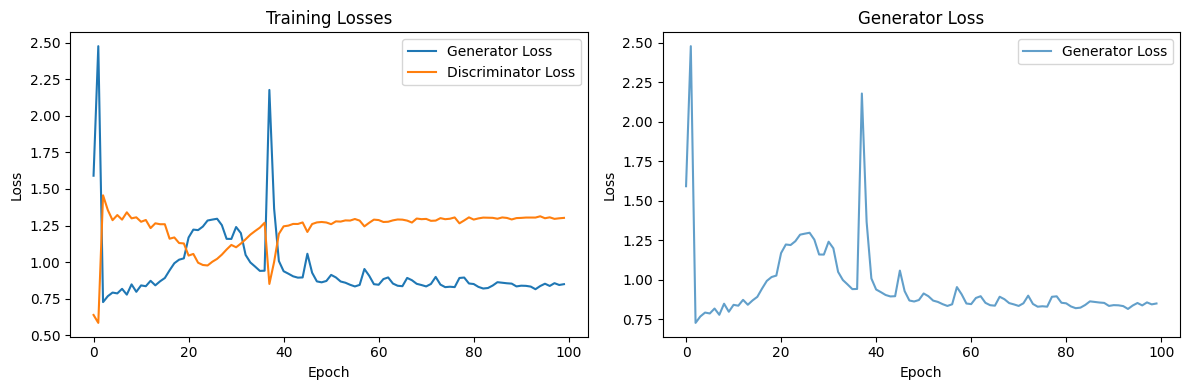


6. Generating final sample images...


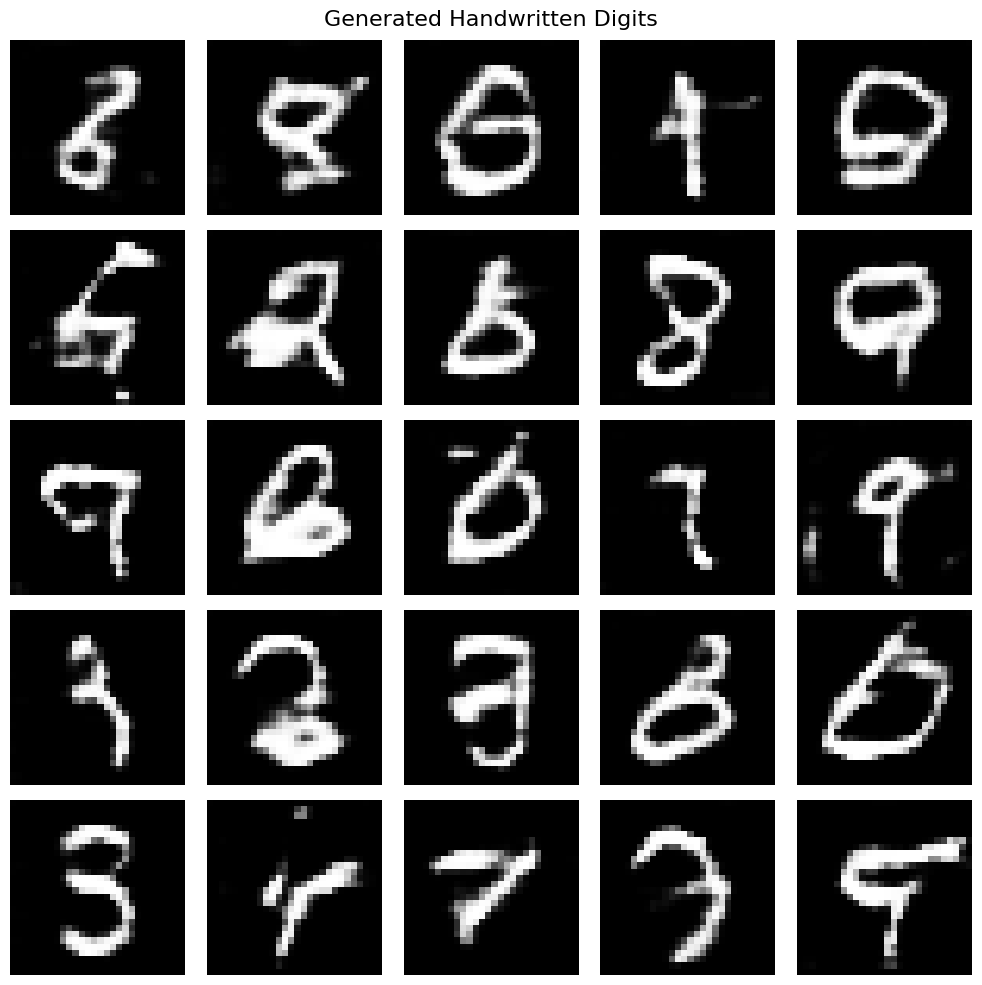


TRAINING COMPLETED SUCCESSFULLY!
Generated images saved in 'generated_images' folder
Model checkpoints saved in 'training_checkpoints' folder


ValueError: The filename must end in `.weights.h5`. Received: filepath=./final_generator_weights

In [29]:
if __name__ == "__main__":
    # Run the complete DCGAN training
    generator, discriminator, gen_losses, disc_losses = main()

    # Optional: Save the final models
    generator.save_weights('./final_generator_weights')
    discriminator.save_weights('./final_discriminator_weights')
    print("\nFinal model weights saved!")

In [30]:
def generate_new_digits(generator, num_images=10, latent_dim=100):
    """Generate new handwritten digits"""
    noise = tf.random.normal([num_images, latent_dim])
    generated_images = generator(noise, training=False)

    # Plot generated images
    cols = min(5, num_images)
    rows = (num_images + cols - 1) // cols

    plt.figure(figsize=(cols*2, rows*2))
    for i in range(num_images):
        plt.subplot(rows, cols, i+1)
        plt.imshow(generated_images[i, :, :, 0] * 127.5 + 127.5, cmap='gray')
        plt.axis('off')
        plt.title(f'Generated #{i+1}')

    plt.tight_layout()
    plt.show()

    return generated_images